# Lab 8.4.3 - Add Interactivity: User Input and Callbacks

## Exercise 1 - Average Monthly Arrival Delay Time
### Theme
Extract the average monthly arrival delay time and see how it changes over the year. The year range is from 2010 to 2020.

### Expected Output
The dashboard should consist of the following:
- Title - same as in the previous lab
- Input component - A field that allows user input of year
- Graph of the month vs average arrival delay time.

![Sample-dashboard](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/Module%204/lab2_output.png)

### Tasks
1. Import libraries and read the dataset
2. Creating app layout and adding the title
3. Add input text box, callback decorator, and generate the line chart inside the callback function

---

### Task 1 - Import libraries and read the dataset

In [1]:
# Import libraries
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, html, dcc, callback, Output, Input

# Read the dataset
path = '/'.join(['https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud',
                 'IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/airline_data.csv'])
airline_data = pd.read_csv(path)
airline_data.set_index('Year', inplace=True) #set index to Year

/Users/jelo/anaconda3/envs/IBM-DS/lib/python3.14/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


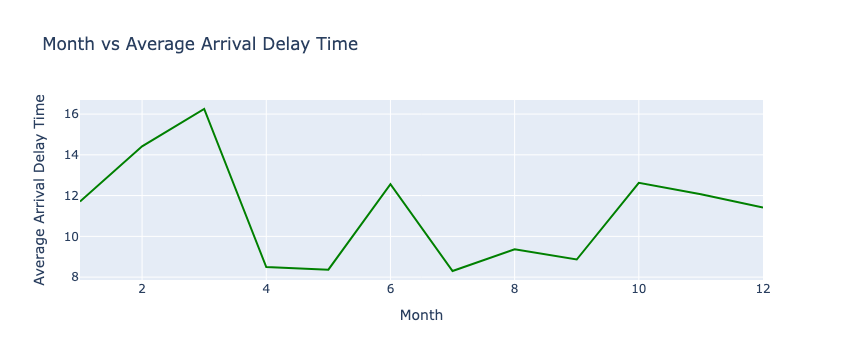

In [2]:
# Sample line graph
grouped = airline_data.loc[2010,['Month','ArrDelayMinutes']].groupby('Month').mean().reset_index()
px.line(grouped, x='Month', y='ArrDelayMinutes',
        title='Month vs Average Arrival Delay Time',
        labels={'ArrDelayMinutes':'Average Arrival Delay Time'},
        color_discrete_sequence=['green'])

### Task 2 - Creating app layout and adding the title

In [4]:
# Initialize the app
app = Dash()

In [ ]:
# App layout
app.layout = [html.H1(...),  # <-- Title
             html.Div(children=['Input Year: ',....]),  # <-- Input Box inside Div children
             dcc.Graph(....)]  # <-- Graph 

In [ ]:
# App layout
app.layout = [html.H1('Airline Dashboard',
                      style={'color': '#503D36',
                             'font-size': 30,
                             'textAlign': 'center'}),
             html.Div(children=['Input Year: ',....]),  # <-- Input Box inside Div children
             dcc.Graph(....)]  # <-- Graph 

### Task 3 - Input text box, callback decorator, and line chart

In [ ]:
# App layout
app.layout = [html.H1('Airline Dashboard',
                      style={'color': '#503D36',
                             'font-size': 30,
                             'textAlign': 'center'}),
             html.Div(children=['Input Year: ',
                                dcc.Input(type='number',
                                          value=2010,
                                          id='controls-and-input')]),
             dcc.Graph(....)]  # <-- Graph 

In [5]:
# App layout
app.layout = [html.H1('Airline Dashboard',
                      style={'color': '#503D36',
                             'font-size': 30,
                             'textAlign': 'center'}),
             html.Div(['Input Year: ',
                        dcc.Input(type='number',
                                  value=2010,
                                  id='controls-and-input',
                                  min=2010,
                                  max=2020)]),
             dcc.Graph(figure={}, id='controls-and-graph')]

In [6]:
# Add controls to build the interaction
@callback(
    Output(component_id='controls-and-graph', component_property='figure'),
    Input(component_id='controls-and-input', component_property='value')
)
def update_graph(year_chosen):
    grouped = airline_data.loc[year_chosen,['Month','ArrDelayMinutes']].groupby('Month').mean().reset_index()
    fig = px.line(grouped, x='Month', y='ArrDelayMinutes',
                  title='Month vs Average Arrival Delay Time',
                  labels={'ArrDelayMinutes':'Average Arrival Delay Time'},
                  color_discrete_sequence=['green'])
    return fig

# Run the app
if __name__ == '__main__':
    app.run(jupyter_mode="external")

Dash app running on http://127.0.0.1:8050/


## Exercise 2 - Total number of flights to destination state